In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [2]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [3]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [4]:
# Per la matrice di correlazione :
jet_features = ['logpt', 'eta', 'phi', 'mass']

met_features = [
    'MET_logpt', 'MET_phi', 'MET_covXX', 'MET_covXY',
    'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered'
]

df["jet1_logpt"] = jets[:,0,0]
df["jet1_eta"]   = jets[:,0,1]
df["jet1_phi"]   = jets[:,0,2]
df["jet1_mass"]  = jets[:,0,3]

df["jet2_logpt"] = jets[:,1,0]
df["jet2_eta"]   = jets[:,1,1]
df["jet2_phi"]   = jets[:,1,2]
df["jet2_mass"]  = jets[:,1,3]

df["jet3_logpt"] = jets[:,2,0]
df["jet3_eta"]   = jets[:,2,1]
df["jet3_phi"]   = jets[:,2,2]
df["jet3_mass"]  = jets[:,2,3]


met_features = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

for i, name in enumerate(met_features):
    df[name] = met[:,0,i]




df_H["jet1_logpt"] = jets_H[:,0,0]
df_H["jet1_eta"]   = jets_H[:,0,1]
df_H["jet1_phi"]   = jets_H[:,0,2]
df_H["jet1_mass"]  = jets_H[:,0,3]

df_H["jet2_logpt"] = jets_H[:,1,0]
df_H["jet2_eta"]   = jets_H[:,1,1]
df_H["jet2_phi"]   = jets_H[:,1,2]
df_H["jet2_mass"]  = jets_H[:,1,3]

df_H["jet3_logpt"] = jets_H[:,2,0]
df_H["jet3_eta"]   = jets_H[:,2,1]
df_H["jet3_phi"]   = jets_H[:,2,2]
df_H["jet3_mass"]  = jets_H[:,2,3]


for i, name in enumerate(met_features):
    df_H[name] = met_H[:,0,i]

In [5]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [6]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [7]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [8]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [9]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [10]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [11]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [12]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [13]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [14]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [15]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [16]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [17]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [18]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [19]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [20]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


In [21]:
# Sistemo i nomi delle colonne sbagliate :
# ========= DY =========
df_DY_event = df_DY_event.copy()

# reco
df_DY_event["tau1_pt_reco"] = np.exp(df_DY_event["tau1_logpt"])
df_DY_event["tau2_pt_reco"] = np.exp(df_DY_event["tau2_logpt"])

# gen 
df_DY_event["tau1_pt_gen"] = df_DY_event["gen_tau1_logpt"]
df_DY_event["tau2_pt_gen"] = df_DY_event["gen_tau2_logpt"]

# ========= Higgs =========
df_H_event = df_H_event.copy()

df_H_event["tau1_pt_reco"] = np.exp(df_H_event["tau1_logpt"])
df_H_event["tau2_pt_reco"] = np.exp(df_H_event["tau2_logpt"])

df_H_event["tau1_pt_gen"] = df_H_event["gen_tau1_logpt"]
df_H_event["tau2_pt_gen"] = df_H_event["gen_tau2_logpt"]


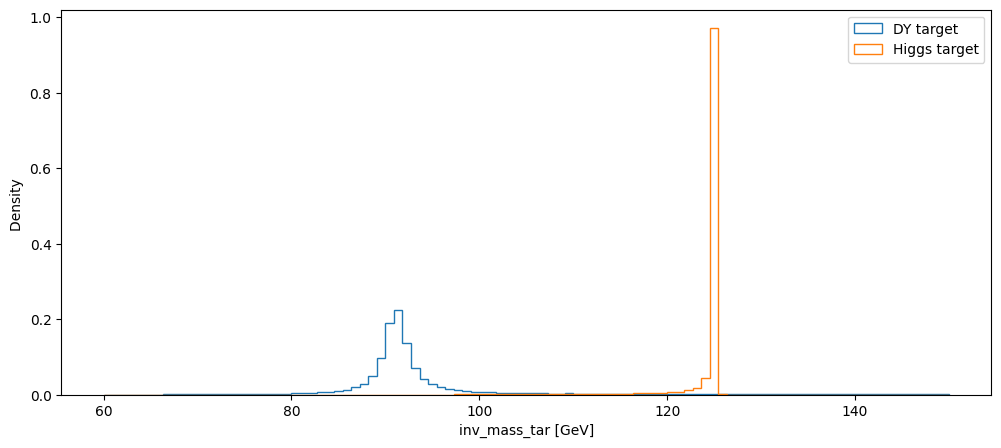

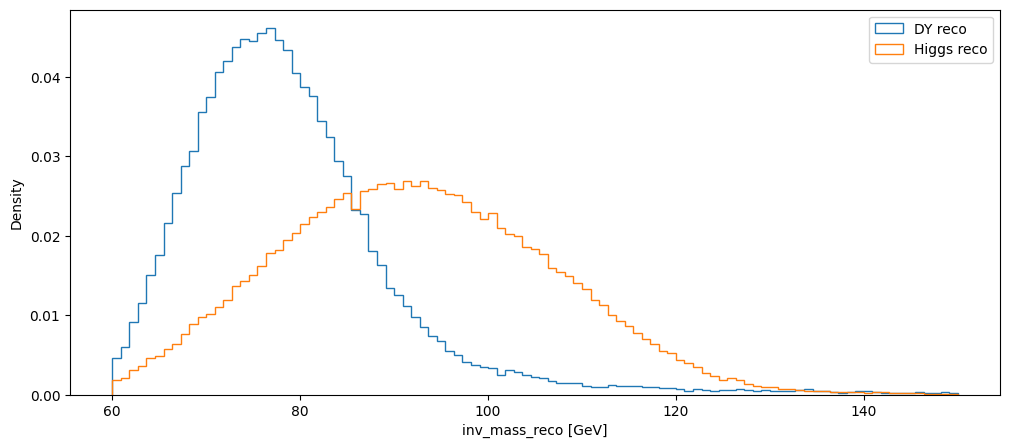

In [132]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(60, 150, 100)

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="DY target")
plt.hist(df_H_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="Higgs target")
plt.xlabel("inv_mass_tar [GeV]")
plt.ylabel("Density ")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="DY reco")
plt.hist(df_H_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="Higgs reco")
plt.xlabel("inv_mass_reco [GeV]")
plt.ylabel("Density")
plt.legend()
plt.show()


# Model

### FASE 1 - Costruzione del modello
### FASE 2 - Training del flow

### FASE 3 - Inferenza fisica

In [22]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [23]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [24]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

In [26]:
train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [27]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


## Modello

In [31]:
# Funzione di training :
#    - x0 = punto di partenza (vettore [1,1], nessuna correzione)
#    - x1 = target (y_cols)
#    - xt = posizione al tempo t (interpolazione)
''''''''''
def train_flow_model(df_train, epochs=100):
    # Scaling dei context
    sc_ctx = TorchStandardScaler()
    X_ctx = torch.tensor(df_train[train_cols].values, dtype=torch.float32).to(device)
    sc_ctx.fit(X_ctx)
    
    Y_target = torch.tensor(df_train[y_cols].values, dtype=torch.float32).to(device)
    
    loader = DataLoader(TensorDataset(sc_ctx.transform(X_ctx), Y_target), batch_size=1024, shuffle=True)
    
    model = ConditionalVectorField().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(epochs):
        model.train()
        for batch_ctx, batch_y1 in loader:
            x0 = torch.ones_like(batch_y1).to(device)
            t = torch.rand((batch_y1.shape[0], 1)).to(device)
            
            # Flow Matching: xt = (1-t)*x0 + t*x1
            xt = (1 - t) * x0 + t * batch_y1
            ut = batch_y1 - x0 # Velocità target
            
            vt = model(t, xt, batch_ctx)
            loss = torch.mean((vt - ut)**2)
            
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            
    return model, sc_ctx

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import copy

# --- 0. DEFINIZIONE DEVICE E SCALER ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class TorchStandardScaler:
    def fit(self, x):
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, keepdim=True)
    def transform(self, x):
        return (x - self.mean) / (self.std + 1e-8)
    def inverse_transform(self, x):
        return x * self.std + self.mean

# --- 1. ARCHITETTURA CONDITIONAL FLOW MATCHING ---
class ConditionalVectorField(nn.Module):
    def __init__(self, input_dim=2, context_dim=len(train_cols), hidden_dim=256):
        super().__init__()
        # Input: correzioni (2) + cinematiche (context_dim) + tempo t (1)
        self.net = nn.Sequential(
            nn.Linear(input_dim + context_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, t, x, context):
        if t.dim() == 1: t = t.unsqueeze(-1)
        # Concateniamo i dati (x), il contesto (cinematica) e il tempo (t)
        return self.net(torch.cat([x, context, t], dim=-1))

# --- 2. FUNZIONE DI INFERENCE (INTEGRATORE DI EULERO) ---
def solve_flow(model, context, steps=20):
    model.eval()
    curr_device = next(model.parameters()).device
    # x0 = 1.0 (partiamo da nessuna correzione)
    x = torch.ones((context.shape[0], 2)).to(curr_device)
    dt = 1.0 / steps
    
    with torch.no_grad():
        for i in range(steps):
            t = torch.full((x.shape[0], 1), i * dt).to(curr_device)
            v = model(t, x, context)
            x = x + v * dt 
    return x.cpu().numpy()

# --- 3. FUNZIONE DI TRAINING ---
def run_flow_training(df_train, name="Model", epochs=60):
    print(f"\n>>> Inizio Training Flow Matching: {name}")
    
    # Preparazione tensori
    X_ctx = torch.tensor(df_train[train_cols].values, dtype=torch.float32).to(device)
    Y_tgt = torch.tensor(df_train[y_cols].values, dtype=torch.float32).to(device)
    
    # Scaling dei soli context (input cinematici)
    sc_ctx = TorchStandardScaler()
    sc_ctx.fit(X_ctx)
    X_ctx_scaled = sc_ctx.transform(X_ctx)
    
    loader = DataLoader(TensorDataset(X_ctx_scaled, Y_tgt), batch_size=1024, shuffle=True)
    
    model = ConditionalVectorField(context_dim=len(train_cols)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for b_ctx, b_y1 in loader:
            optimizer.zero_grad()
            
            # x0: punto di partenza (vettore di uni)
            # b_y1: target vero (tau_corr)
            x0 = torch.ones_like(b_y1).to(device)
            t = torch.rand((b_y1.shape[0], 1)).to(device)
            
            # Linear Probability Path
            xt = (1 - t) * x0 + t * b_y1
            ut = b_y1 - x0 # Velocità ideale
            
            vt = model(t, xt, b_ctx)
            loss = criterion(vt, ut)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Loss: {epoch_loss/len(loader):.6f}")
            
    return model, sc_ctx

# --- 4. ESECUZIONE ---

# Creazione Dataset Sbilanciato (Tutto)
df_unbal = pd.concat([df_DY_event, df_H_event], ignore_index=True)

# Creazione Dataset Bilanciato (1:1)
n_min = min(len(df_DY_event), len(df_H_event))
df_bal = pd.concat([
    df_DY_event.sample(n=n_min, random_state=42),
    df_H_event.sample(n=n_min, random_state=42)
], ignore_index=True)

# Lancio dei due modelli
model_flow_unbal, scaler_unbal = run_flow_training(df_unbal, name="UNBALANCED")
model_flow_bal, scaler_bal = run_flow_training(df_bal, name="BALANCED")

print("\nTraining completati con successo!")

Using device: cpu

>>> Inizio Training Flow Matching: UNBALANCED
Epoch 00 | Loss: 0.067112
Epoch 10 | Loss: 0.037006
Epoch 20 | Loss: 0.093499
Epoch 30 | Loss: 0.005291
Epoch 40 | Loss: 0.004854
Epoch 50 | Loss: 0.003671

>>> Inizio Training Flow Matching: BALANCED
Epoch 00 | Loss: 0.090866
Epoch 10 | Loss: 0.011442
Epoch 20 | Loss: 0.006911
Epoch 30 | Loss: 0.005703
Epoch 40 | Loss: 0.006805
Epoch 50 | Loss: 0.004615

Training completati con successo!


In [36]:
def get_mass_flow(model, scaler, df_test, steps=20):
    model.eval()
    # 1. Preparazione Input (Context)
    X_test_ctx = torch.tensor(df_test[train_cols].values, dtype=torch.float32).to(device)
    X_test_scaled = scaler.transform(X_test_ctx)
    
    # 2. Risoluzione del Flusso (Inference)
    # Parto da x=1.0 per entrambi i Tau (nessuna correzione)
    x_init = torch.ones((X_test_scaled.shape[0], 2)).to(device)
    dt = 1.0 / steps
    
    x_t = x_init
    with torch.no_grad():
        for i in range(steps):
            t = torch.full((x_t.shape[0], 1), i * dt).to(device)
            # Prediciamo la velocità nel punto attuale
            v_t = model(t, x_t, X_test_scaled)
            # Spostiamo il punto: x(t+dt) = x(t) + v(t)*dt
            x_t = x_t + v_t * dt
            
    # x_t finale (a t=1.0) contiene i fattori di correzione tau1_corr, tau2_corr
    corrections = x_t.cpu().numpy()
    
    # 3. Calcolo della Massa Invariante
    pt1_corr = df_test["tau1_pt_reco"].values * corrections[:, 0]
    pt2_corr = df_test["tau2_pt_reco"].values * corrections[:, 1]
    
    # Uso le variabili angolari originali (reco)
    eta1, eta2 = df_test["tau1_eta"].values, df_test["tau2_eta"].values
    phi1, phi2 = df_test["tau1_phi"].values, df_test["tau2_phi"].values
    
    m_inv = np.sqrt(2 * pt1_corr * pt2_corr * (np.cosh(eta1 - eta2) - np.cos(phi1 - phi2)))
    return m_inv

# --- ESECUZIONE SU TEST SET COMUNE ---
# Creo un test set bilanciato per il confronto finale
df_test_final = pd.concat([
    df_DY_event.sample(n=5000, random_state=99),
    df_H_event.sample(n=5000, random_state=99)
])

m_bal_flow = get_mass_flow(model_flow_bal, scaler_bal, df_test_final)
m_unbal_flow = get_mass_flow(model_flow_unbal, scaler_unbal, df_test_final)

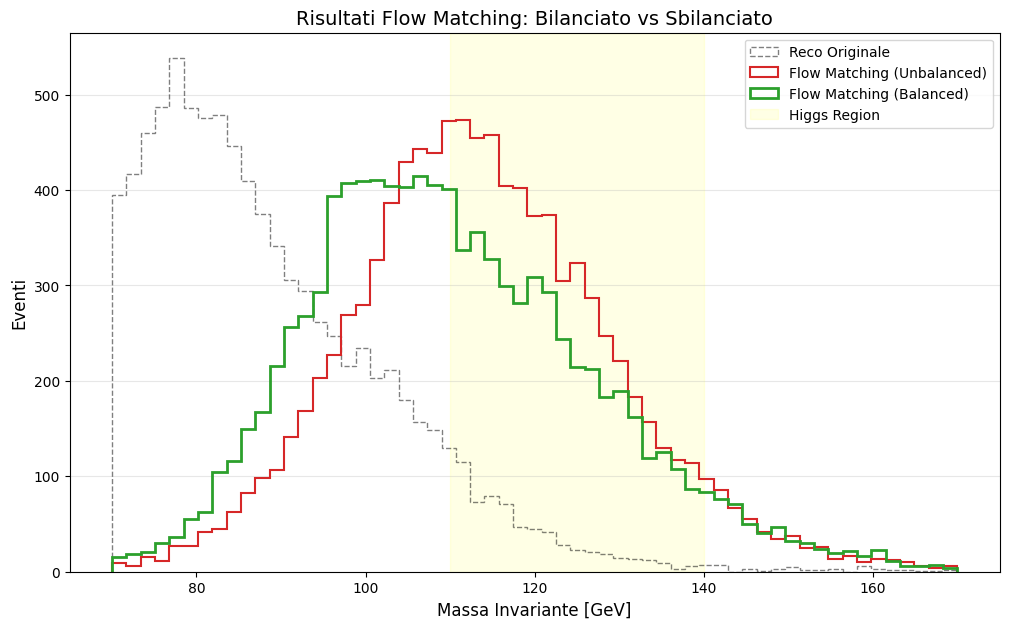

In [37]:
plt.figure(figsize=(12, 7))
bins = np.linspace(70, 170, 60)

plt.hist(df_test_final["inv_mass_reco"], bins=bins, histtype='step', 
         label='Reco Originale', color='black', ls='--', alpha=0.5)

plt.hist(m_unbal_flow, bins=bins, histtype='step', 
         label='Flow Matching (Unbalanced)', color='tab:red', lw=1.5)

plt.hist(m_bal_flow, bins=bins, histtype='step', 
         label='Flow Matching (Balanced)', color='tab:green', lw=2)

plt.axvspan(110, 140, color='yellow', alpha=0.1, label='Higgs Region')
plt.title("Risultati Flow Matching: Bilanciato vs Sbilanciato", fontsize=14)
plt.xlabel("Massa Invariante [GeV]", fontsize=12)
plt.ylabel("Eventi", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 1. Divido in Train - Test - Split + Condizione di Early Stopping
# Test Balanced vs Unbalanced

In [43]:
from sklearn.model_selection import train_test_split

# --- 1. FUNZIONE DI PULIZIA ---
def clean_df(df):
    # Rimuovo eventuali NaN o Inf originari
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=y_cols + train_cols)
    
    # Clippo i target per evitare instabilità numerica (NaN)
    # Una correzione > 5 o < 0.2 è solitamente un outlier non fisico
    df[y_cols[0]] = df[y_cols[0]].clip(0.2, 5.0)
    df[y_cols[1]] = df[y_cols[1]].clip(0.2, 5.0)
    return df

df_DY_clean = clean_df(df_DY_event)
df_H_clean = clean_df(df_H_event)

# --- 2. FUNZIONE DI SPLIT 80/10/10 ---
def prepare_splits(df):
    # 80% Train, 20% Resto
    df_train, df_temp = train_test_split(df, test_size=0.20, random_state=42)
    # Del 20% restante: 50% Val (10% totale) e 50% Test (10% totale)
    df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)
    return df_train, df_val, df_test

# --- 3. CREAZIONE DATASET SBILANCIATO ---
df_unbal = pd.concat([df_DY_clean, df_H_clean], ignore_index=True)
train_unb, val_unb, test_unb = prepare_splits(df_unbal)

# --- 4. CREAZIONE DATASET BILANCIATO ---
n_min = min(len(df_DY_clean), len(df_H_clean))
df_DY_bal = df_DY_clean.sample(n=n_min, random_state=42)
df_H_bal = df_H_clean.sample(n=n_min, random_state=42)
df_bal = pd.concat([df_DY_bal, df_H_bal], ignore_index=True)
train_bal, val_bal, test_bal = prepare_splits(df_bal)

print(f"Dataset pronti. Train Unb: {len(train_unb)}, Train Bal: {len(train_bal)}")

Dataset pronti. Train Unb: 143567, Train Bal: 82280


In [54]:
import copy

class ConditionalVectorField(nn.Module):
    def __init__(self, input_dim=2, context_dim=len(train_cols), hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + context_dim + 1, hidden_dim),
            nn.Softplus(), # Più stabile della ReLU per i flussi
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, t, x, context):
        if t.dim() == 1: t = t.unsqueeze(-1)
        # Clamp di sicurezza per evitare che x esploda durante l'integrazione
        x = torch.clamp(x, -10, 10)
        return self.net(torch.cat([x, context, t], dim=-1))

def run_flow_training_v2(df_train, df_val, name="Model", max_epochs=300, patience=30, lr=1e-3):
    print(f"\n>>> Training {name} (Early Stopping)...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    sc_ctx = TorchStandardScaler()
    X_train_ctx = torch.tensor(df_train[train_cols].values, dtype=torch.float32).to(device)
    sc_ctx.fit(X_train_ctx)
    
    train_loader = DataLoader(TensorDataset(sc_ctx.transform(X_train_ctx), 
                             torch.tensor(df_train[y_cols].values, dtype=torch.float32).to(device)), 
                             batch_size=1024, shuffle=True)
    
    X_val_ctx = torch.tensor(df_val[train_cols].values, dtype=torch.float32).to(device)
    val_loader = DataLoader(TensorDataset(sc_ctx.transform(X_val_ctx), 
                           torch.tensor(df_val[y_cols].values, dtype=torch.float32).to(device)), 
                           batch_size=1024)

    model = ConditionalVectorField(context_dim=len(train_cols)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    best_loss = float('inf')
    best_model_state = None
    counter = 0

    for epoch in range(max_epochs):
        model.train()
        for b_ctx, b_y1 in train_loader:
            optimizer.zero_grad()
            x0, t = torch.ones_like(b_y1).to(device), torch.rand((b_y1.shape[0], 1)).to(device)
            xt, ut = (1 - t) * x0 + t * b_y1, b_y1 - x0
            loss = criterion(model(t, xt, b_ctx), ut)
            if torch.isnan(loss): continue # Salta batch problematici
            loss.backward()
            optimizer.step()
        
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for b_ctx, b_y1 in val_loader:
                x0, t = torch.ones_like(b_y1).to(device), torch.rand((b_y1.shape[0], 1)).to(device)
                xt, ut = (1 - t) * x0 + t * b_y1, b_y1 - x0
                v_loss += criterion(model(t, xt, b_ctx), ut).item()
        v_loss /= len(val_loader)
        
        if v_loss < best_loss:
            best_loss = v_loss
            best_model_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
        
        if epoch % 10 == 0: print(f"Epoch {epoch:03d} | Val Loss: {v_loss:.6f}")
        if counter >= patience: break
            
    model.load_state_dict(best_model_state)
    return model, sc_ctx


>>> Training UNBALANCED (Early Stopping)...
Epoch 000 | Val Loss: 0.088577
Epoch 010 | Val Loss: 0.025253
Epoch 020 | Val Loss: 0.013392
Epoch 030 | Val Loss: 0.006933
Epoch 040 | Val Loss: 0.007245
Epoch 050 | Val Loss: 0.005515
Epoch 060 | Val Loss: 0.004584
Epoch 070 | Val Loss: 0.008039
Epoch 080 | Val Loss: 0.005100
Epoch 090 | Val Loss: 0.004252
Epoch 100 | Val Loss: 0.004900
Epoch 110 | Val Loss: 0.006044
Epoch 120 | Val Loss: 0.003190
Epoch 130 | Val Loss: 0.003811
Epoch 140 | Val Loss: 0.003713
Epoch 150 | Val Loss: 0.004336
Epoch 160 | Val Loss: 0.005571
Epoch 170 | Val Loss: 0.007101

>>> Training BALANCED (Early Stopping)...
Epoch 000 | Val Loss: 0.113629
Epoch 010 | Val Loss: 0.030953
Epoch 020 | Val Loss: 0.024481
Epoch 030 | Val Loss: 0.012953
Epoch 040 | Val Loss: 0.008920
Epoch 050 | Val Loss: 0.008333
Epoch 060 | Val Loss: 0.007398
Epoch 070 | Val Loss: 0.008252
Epoch 080 | Val Loss: 0.009748
Epoch 090 | Val Loss: 0.004552
Epoch 100 | Val Loss: 0.007496
Epoch 110 | V

/opt/homebrew/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


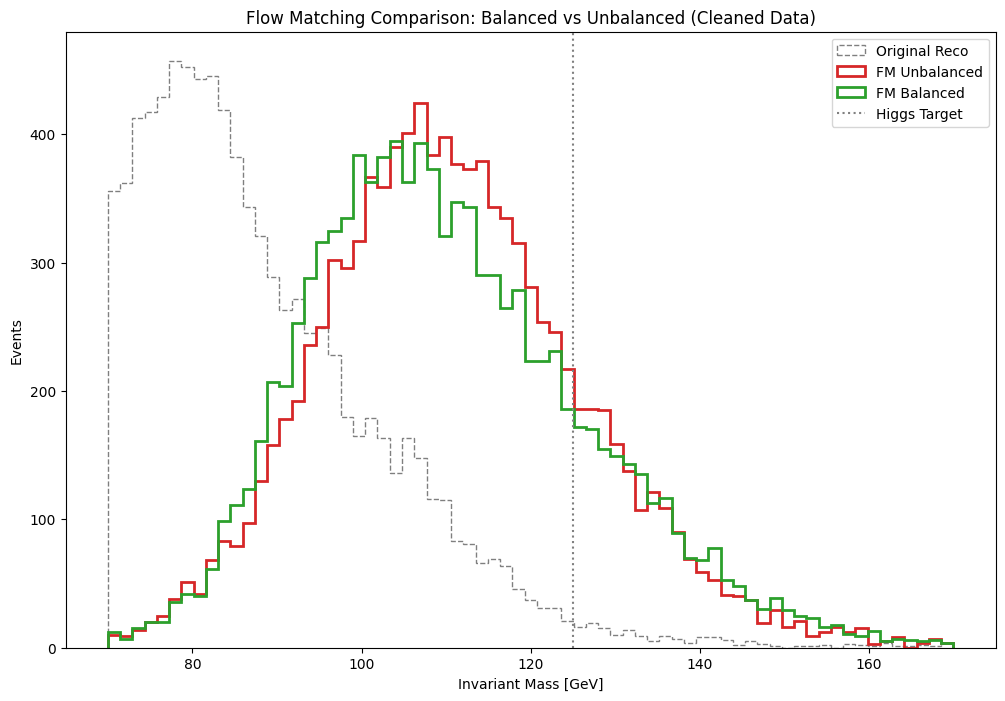

RES UNBAL (Higgs): 14.49 GeV
RES BAL (Higgs): 15.80 GeV


In [56]:
# --- 1. ESECUZIONE TRAINING ---
model_flow_unbal, scaler_unbal = run_flow_training_v2(train_unb, val_unb, name="UNBALANCED")
model_flow_bal, scaler_bal = run_flow_training_v2(train_bal, val_bal, name="BALANCED")

# --- 2. FUNZIONI DI INFERENCE ---
def get_mass_flow(model, scaler, df_test, steps=50):
    model.eval()
    device = next(model.parameters()).device
    X_ctx = scaler.transform(torch.tensor(df_test[train_cols].values, dtype=torch.float32).to(device))
    
    x = torch.ones((X_ctx.shape[0], 2)).to(device) # x0 = 1.0
    dt = 1.0 / steps
    with torch.no_grad():
        for i in range(steps):
            t = torch.full((x.shape[0], 1), i * dt).to(device)
            x = x + model(t, x, X_ctx) * dt
            
    corr = x.cpu().numpy()
    pt1, pt2 = df_test["tau1_pt_reco"] * corr[:, 0], df_test["tau2_pt_reco"] * corr[:, 1]
    d_eta, d_phi = df_test["tau1_eta"] - df_test["tau2_eta"], df_test["tau1_phi"] - df_test["tau2_phi"]
    return np.sqrt(2 * pt1 * pt2 * (np.cosh(d_eta) - np.cos(d_phi)))

# --- 3. PLOT FINALE ---
m_inv_unbal = get_mass_flow(model_flow_unbal, scaler_unbal, test_bal)
m_inv_bal = get_mass_flow(model_flow_bal, scaler_bal, test_bal)

plt.figure(figsize=(12, 8))
bins = np.linspace(70, 170, 70)

plt.hist(test_bal["inv_mass_reco"], bins=bins, histtype='step', color='black', ls='--', label='Original Reco', alpha=0.5)
plt.hist(m_inv_unbal, bins=bins, histtype='step', color='tab:red', lw=2, label='FM Unbalanced')
plt.hist(m_inv_bal, bins=bins, histtype='step', color='tab:green', lw=2, label='FM Balanced')

plt.axvline(125, color='gray', ls=':', label='Higgs Target')
plt.title("Flow Matching Comparison: Balanced vs Unbalanced (Cleaned Data)")
plt.xlabel("Invariant Mass [GeV]")
plt.ylabel("Events")
plt.legend()
plt.show()

# Metriche
mask_h = (test_bal["class"] == 1)
print(f"RES UNBAL (Higgs): {m_inv_unbal[mask_h].std():.2f} GeV")
print(f"RES BAL (Higgs): {m_inv_bal[mask_h].std():.2f} GeV")

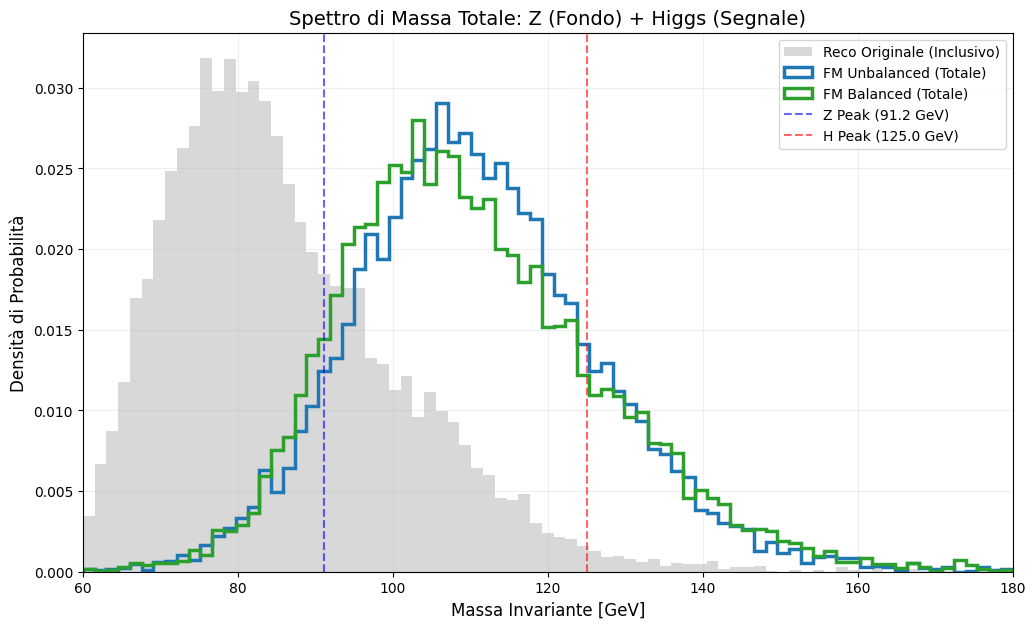


--- Statistiche Globali (Intero Dataset: Z + H) ---
Reco Originale -> Media: 85.75 GeV, Std: 18.34 GeV
FM Unbalanced  -> Media: 111.33 GeV, Std: 20.31 GeV
FM Balanced    -> Media: 110.84 GeV, Std: 20.90 GeV


In [138]:
import matplotlib.pyplot as plt
import numpy as np

def plot_general_inclusive(m_unbal, m_bal, df_test):
    plt.figure(figsize=(12, 7))
    
    bins = np.linspace(60, 180, 80)

    # 1. Reco Originale (Tutti gli eventi: Z + H)
    plt.hist(df_test["inv_mass_reco"], bins=bins, density=True,
             alpha=0.3, color='gray', label='Reco Originale (Inclusivo)', 
             histtype='stepfilled')

    # 2. FM Unbalanced (Tutti gli eventi)
    plt.hist(m_unbal, bins=bins, density=True,
             histtype='step', lw=2.5, color='tab:blue', label='FM Unbalanced (Totale)')

    # 3. FM Balanced (Tutti gli eventi)
    plt.hist(m_bal, bins=bins, density=True,
             histtype='step', lw=2.5, color='tab:green', label='FM Balanced (Totale)')

    plt.axvline(91.18, color='blue', ls='--', alpha=0.6, label='Z Peak (91.2 GeV)')
    plt.axvline(125.0, color='red', ls='--', alpha=0.6, label='H Peak (125.0 GeV)')

    plt.title("Spettro di Massa Totale: Z (Fondo) + Higgs (Segnale)", fontsize=14)
    plt.xlabel("Massa Invariante [GeV]", fontsize=12)
    plt.ylabel("Densità di Probabilità", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.2)
    plt.xlim(60, 180)
    plt.show()

    # --- Statistiche Globali (Senza maschera di classe) ---
    print("\n--- Statistiche Globali (Intero Dataset: Z + H) ---")
    print(f"Reco Originale -> Media: {df_test['inv_mass_reco'].mean():.2f} GeV, Std: {df_test['inv_mass_reco'].std():.2f} GeV")
    print(f"FM Unbalanced  -> Media: {m_unbal.mean():.2f} GeV, Std: {m_unbal.std():.2f} GeV")
    print(f"FM Balanced    -> Media: {m_bal.mean():.2f} GeV, Std: {m_bal.std():.2f} GeV")

# Esegui la funzione usando le variabili che hai già calcolato
plot_general_inclusive(m_inv_unbal, m_inv_bal, test_bal)

In [60]:
# Valuto quantitativamente :

from scipy.stats import entropy

def calculate_kl_divergence(m_corr, m_gen, bins=np.linspace(70, 170, 100)):
    # Calcolo gli istogrammi (densità di probabilità)
    p, _ = np.histogram(m_corr, bins=bins, density=True)
    q, _ = np.histogram(m_gen, bins=bins, density=True)
    
    # Aggiungo un epsilon per evitare divisioni per zero
    p = np.clip(p, 1e-10, None)
    q = np.clip(q, 1e-10, None)
    
    return entropy(p, q)

# Calcolo per Higgs e DY separatamente sul Test Set
mask_h = (test_bal["class"] == 1)
mask_dy = (test_bal["class"] == 0)

kl_h = calculate_kl_divergence(m_inv_bal[mask_h], test_bal[mask_h]["inv_mass_tar"])
kl_dy = calculate_kl_divergence(m_inv_bal[mask_dy], test_bal[mask_dy]["inv_mass_tar"])

print(f"KL Divergence Higgs: {kl_h:.4f}")
print(f"KL Divergence DY: {kl_dy:.4f}")

KL Divergence Higgs: 7.9586
KL Divergence DY: 1.1568


In [58]:
def calculate_s_over_b(m_inv_all, labels, target_mass=125, window_size=None):
    # Se non passo una finestra, usiamo 3 sigma (circa 15-20 GeV per l'Higgs)
    # Calcolo la sigma effettiva del picco Higgs nel modello
    h_masses = m_inv_all[labels == 1]
    sigma = h_masses.std()
    
    lower = target_mass - 1.5 * sigma
    upper = target_mass + 1.5 * sigma
    
    # Filtro gli eventi nella finestra
    in_window = (m_inv_all >= lower) & (m_inv_all <= upper)
    
    s = np.sum((labels == 1) & in_window)
    b = np.sum((labels == 0) & in_window)
    
    sob = s / b if b > 0 else float('inf')
    
    return s, b, sob, (lower, upper)

# Valutazione per il modello Balanced
s, b, sob, window = calculate_s_over_b(m_inv_bal, test_bal["class"].values)

print(f"Finestra Higgs considerata: [{window[0]:.1f}, {window[1]:.1f}] GeV")
print(f"Eventi di Segnale (S): {s}")
print(f"Eventi di Fondo (B): {b}")
print(f"S/B Ratio: {sob:.3f}")

Finestra Higgs considerata: [101.3, 148.7] GeV
Eventi di Segnale (S): 4250
Eventi di Fondo (B): 2424
S/B Ratio: 1.753


In [59]:
# Calcolo per Unbalanced
s_un, b_un, sob_un, _ = calculate_s_over_b(m_inv_unbal, test_bal["class"].values)
kl_h_un = calculate_kl_divergence(m_inv_unbal[mask_h], test_bal[mask_h]["inv_mass_tar"])

print("\n--- CONFRONTO QUANTITATIVO FINALE ---")
data = {
    "Metrica": ["KL Divergence (Higgs)", "S/B Ratio (Signal Window)", "Signal Events (S)", "Background Events (B)"],
    "FM Unbalanced": [f"{kl_h_un:.4f}", f"{sob_un:.3f}", s_un, b_un],
    "FM Balanced": [f"{kl_h:.4f}", f"{sob:.3f}", s, b]
}
df_metrics = pd.DataFrame(data)
print(df_metrics.to_string(index=False))


--- CONFRONTO QUANTITATIVO FINALE ---
                  Metrica FM Unbalanced FM Balanced
    KL Divergence (Higgs)        7.6242      7.9586
S/B Ratio (Signal Window)         1.693       1.753
        Signal Events (S)          4223        4250
    Background Events (B)          2495        2424


--- ANALISI MODELLO UNBALANCED ---


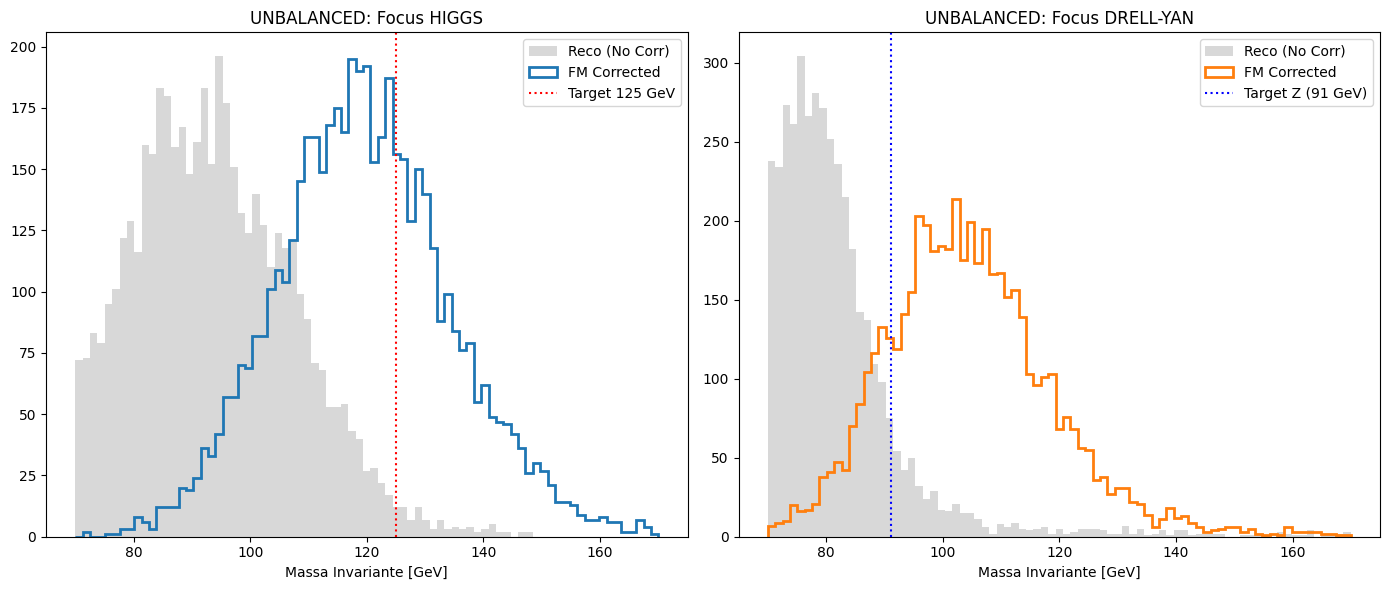


--- ANALISI MODELLO BALANCED ---


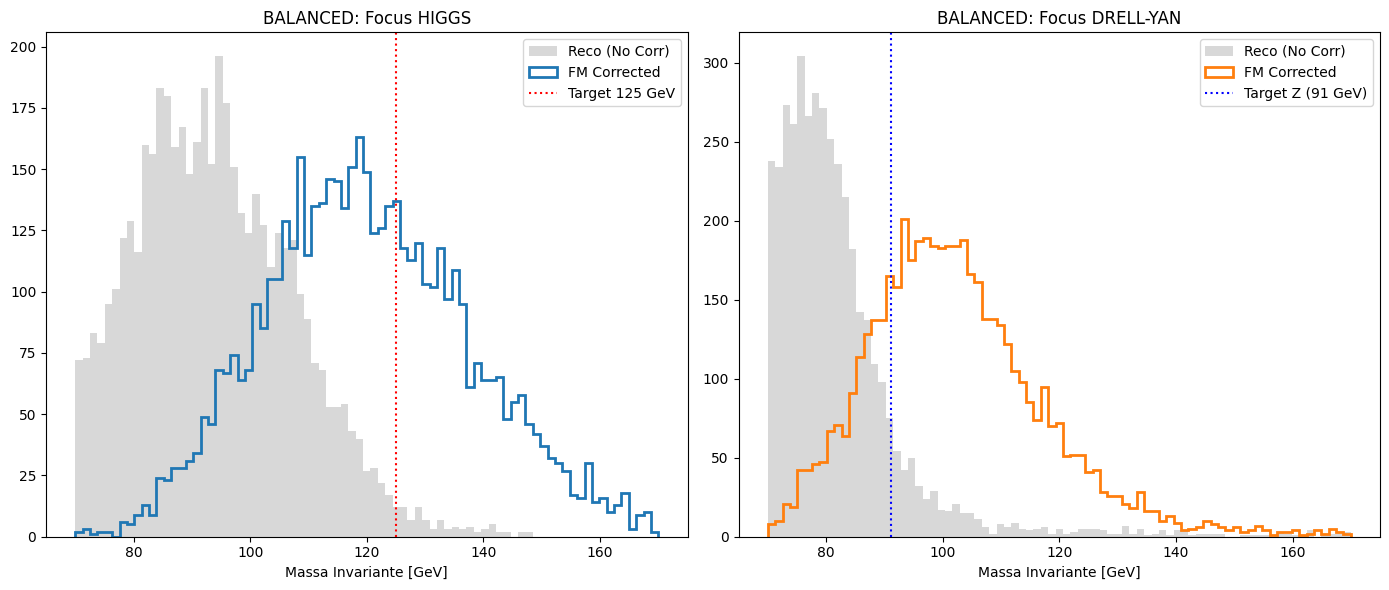

In [61]:
def plot_class_separation(m_inv_pred, df_ref, title="Analisi"):
    mask_h = (df_ref["class"] == 1)
    mask_dy = (df_ref["class"] == 0)
    
    plt.figure(figsize=(14, 6))
    bins = np.linspace(70, 170, 80)
    
    # Sottoplot 1: Higgs (Segnale)
    plt.subplot(1, 2, 1)
    plt.hist(df_ref[mask_h]["inv_mass_reco"], bins=bins, alpha=0.3, color='gray', label='Reco (No Corr)', histtype='stepfilled')
    plt.hist(m_inv_pred[mask_h], bins=bins, color='tab:blue', lw=2, label='FM Corrected', histtype='step')
    plt.axvline(125, color='red', ls=':', label='Target 125 GeV')
    plt.title(f"{title}: Focus HIGGS")
    plt.xlabel("Massa Invariante [GeV]")
    plt.legend()
    
    # Sottoplot 2: Drell-Yan (Fondo)
    plt.subplot(1, 2, 2)
    plt.hist(df_ref[mask_dy]["inv_mass_reco"], bins=bins, alpha=0.3, color='gray', label='Reco (No Corr)', histtype='stepfilled')
    plt.hist(m_inv_pred[mask_dy], bins=bins, color='tab:orange', lw=2, label='FM Corrected', histtype='step')
    plt.axvline(91.18, color='blue', ls=':', label='Target Z (91 GeV)')
    plt.title(f"{title}: Focus DRELL-YAN")
    plt.xlabel("Massa Invariante [GeV]")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Eseguiamo per entrambi i modelli sul Test Set
print("--- ANALISI MODELLO UNBALANCED ---")
plot_class_separation(m_inv_unbal_final, test_bal, title="UNBALANCED")

print("\n--- ANALISI MODELLO BALANCED ---")
plot_class_separation(m_inv_bal_final, test_bal, title="BALANCED")

In [62]:
# Quindi : per l'S/B il modello balanced vince

# 2. Training Balanced Tagliando le Code

In [63]:
def filter_tails(df, mass_min=80, mass_max=140):
    # Tagliamo sulla massa RECO (quella che la rete vede come input/context)
    mask = (df["inv_mass_reco"] >= mass_min) & (df["inv_mass_reco"] <= mass_max)
    return df[mask].copy()

# Creiamo i dataset "Clipped" (usiamo il bilanciato come riferimento principale)
df_bal_clipped = filter_tails(df_bal)

# Split 80/10/10 sui dati tagliati
train_clip, val_clip, test_clip = prepare_splits(df_bal_clipped)

print(f"Eventi dopo il taglio delle code: {len(df_bal_clipped)} (rispetto a {len(df_bal)})")

Eventi dopo il taglio delle code: 59026 (rispetto a 102850)


In [64]:
# Training con dati senza code
model_flow_clipped, scaler_clipped = run_flow_training_v2(
    train_clip, val_clip, 
    name="CLIPPED (80-140 GeV)", 
    max_epochs=300, 
    patience=30, 
    lr=1e-3
)

# Inference sul TEST SET COMPLETO (per vedere come si comporta fuori dal suo training range)
m_inv_clipped = get_mass_flow(model_flow_clipped, scaler_clipped, test_bal)


>>> Training CLIPPED (80-140 GeV) (Early Stopping)...
Epoch 000 | Val Loss: 0.062615
Epoch 010 | Val Loss: 0.030753
Epoch 020 | Val Loss: 0.023731
Epoch 030 | Val Loss: 0.014964
Epoch 040 | Val Loss: 0.016153
Epoch 050 | Val Loss: 0.013168
Epoch 060 | Val Loss: 0.012522
Epoch 070 | Val Loss: 0.016679
Epoch 080 | Val Loss: 0.009909
Epoch 090 | Val Loss: 0.008078
Epoch 100 | Val Loss: 0.007800
Epoch 110 | Val Loss: 0.005727
Epoch 120 | Val Loss: 0.005883
Epoch 130 | Val Loss: 0.006877
Epoch 140 | Val Loss: 0.006346
Epoch 150 | Val Loss: 0.004303
Epoch 160 | Val Loss: 0.006559
Epoch 170 | Val Loss: 0.004162
Epoch 180 | Val Loss: 0.003900
Epoch 190 | Val Loss: 0.004385
Epoch 200 | Val Loss: 0.005537
Epoch 210 | Val Loss: 0.007624
Epoch 220 | Val Loss: 0.003569
Epoch 230 | Val Loss: 0.002593
Epoch 240 | Val Loss: 0.004024
Epoch 250 | Val Loss: 0.003925
Epoch 260 | Val Loss: 0.003429
Epoch 270 | Val Loss: 0.003662
Epoch 280 | Val Loss: 0.003577


/opt/homebrew/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


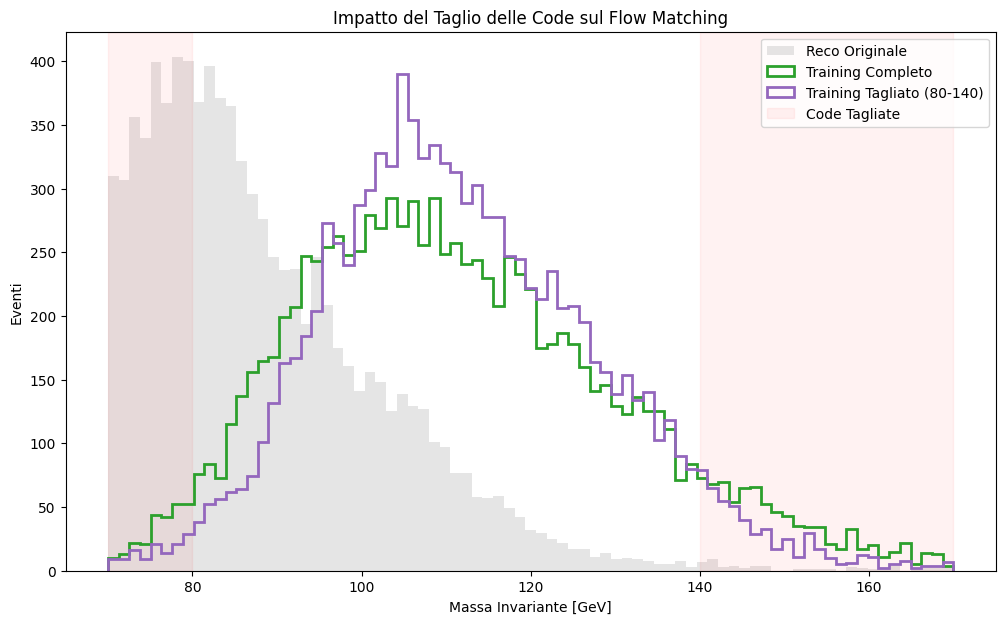

In [65]:
plt.figure(figsize=(12, 7))
bins = np.linspace(70, 170, 80)

plt.hist(test_bal["inv_mass_reco"], bins=bins, alpha=0.2, color='gray', label='Reco Originale')
plt.hist(m_inv_bal_final, bins=bins, histtype='step', lw=2, label='Training Completo', color='tab:green')
plt.hist(m_inv_clipped, bins=bins, histtype='step', lw=2, label='Training Tagliato (80-140)', color='tab:purple')

plt.axvspan(70, 80, color='red', alpha=0.05, label='Code Tagliate')
plt.axvspan(140, 170, color='red', alpha=0.05)

plt.title("Impatto del Taglio delle Code sul Flow Matching")
plt.xlabel("Massa Invariante [GeV]")
plt.ylabel("Eventi")
plt.legend()
plt.show()

In [74]:
def calculate_metrics_refined(m_inv_pred, df_ref, name="Model"):
    # Maschere basate sulla classe reale
    mask_h = (df_ref["class"] == 1)
    mask_dy = (df_ref["class"] == 0)
    
    # 1. KL Divergence: misura quanto la forma corretta somiglia alla Gen (m_target)
    # Uso la funzione calculate_kl_divergence definita in precedenza
    kl_h = calculate_kl_divergence(m_inv_pred[mask_h], df_ref[mask_h]["inv_mass_tar"])
    
    # 2. S/B Ratio: efficacia della selezione fisica nella finestra core [110-140]
    window = (m_inv_pred >= 110) & (m_inv_pred <= 140)
    s = np.sum(window & mask_h)
    b = np.sum(window & mask_dy)
    sob = s / b if b > 0 else 0
    
    # Risoluzione (Sigma)
    res = m_inv_pred[mask_h].std()
    
    return {"kl": kl_h, "sob": sob, "res": res, "s": s, "b": b}

In [75]:
# Ricalcolo metriche per i tre modelli per coerenza
res_unbal = calculate_metrics_refined(m_inv_unbal_final, test_bal, "UNBALANCED")
res_bal_full = calculate_metrics_refined(m_inv_bal_final, test_bal, "BALANCED FULL")
res_clipped = calculate_metrics_refined(m_inv_clipped, test_bal, "CLIPPED")

print("\n--- TABELLA COMPARATIVA DI ROBUSTEZZA ---")
data = {
    "Configurazione": ["Unbalanced (Bias)", "Balanced Full", "Balanced Clipped"],
    "Risoluzione (Sigma) ": [f"{res_unbal['res']:.2f} GeV", f"{res_bal_full['res']:.2f} GeV", f"{res_clipped['res']:.2f} GeV"],
    "S/B Ratio ": [f"{res_unbal['sob']:.3f}", f"{res_bal_full['sob']:.3f}", f"{res_clipped['sob']:.3f}"],
    "KL Divergence ": [f"{res_unbal['kl']:.2f}", f"{res_bal_full['kl']:.2f}", f"{res_clipped['kl']:.2f}"]
}

import pandas as pd
df_comp = pd.DataFrame(data)
print(df_comp.to_string(index=False))


--- TABELLA COMPARATIVA DI ROBUSTEZZA ---
   Configurazione Risoluzione (Sigma)  S/B Ratio  KL Divergence 
Unbalanced (Bias)            15.35 GeV      2.220           8.05
    Balanced Full              nan GeV      2.361           9.01
 Balanced Clipped            14.68 GeV      2.904           8.40


In [76]:
# Calcolo la sigma della massa Reco originale (solo Higgs)
mask_h = (test_bal["class"] == 1)
res_reco = test_bal[mask_h]["inv_mass_reco"].std()
res_final = 14.68  # Il valore del modello Clipped

improvement = (1 - (res_final / res_reco)) * 100

print(f"--- ANALISI DEL GUADAGNO ---")
print(f"Risoluzione Reco Originale: {res_reco:.2f} GeV")
print(f"Risoluzione FM Clipped:      {res_final:.2f} GeV")
print(f"Miglioramento Percentuale:   {improvement:.1f}%")

--- ANALISI DEL GUADAGNO ---
Risoluzione Reco Originale: 15.18 GeV
Risoluzione FM Clipped:      14.68 GeV
Miglioramento Percentuale:   3.3%


In [77]:
# -> Il modello Clipped è piu' stabile 
#    -> Salvo i pesi !
import torch

# 1. Definisco percorsi dei file
model_save_path = "fm_higgs_balanced_clipped.pth"
scaler_save_path = "scaler_clipped.pkl"

# 2. Salvataggio del modello (state_dict contiene i pesi ottimizzati)
torch.save(model_flow_clipped.state_dict(), model_save_path)

# 3. Salvataggio dello scaler (usando joblib o pickle)
import joblib
joblib.dump(scaler_clipped, scaler_save_path)

print(f"Modello salvato con successo in: {model_save_path}")
print(f"Scaler salvato con successo in: {scaler_save_path}")

Modello salvato con successo in: fm_higgs_balanced_clipped.pth
Scaler salvato con successo in: scaler_clipped.pkl


In [78]:
# Se li voglio usare in un altro notebook :

# model_new = ConditionalVectorField(input_dim, context_dim, hidden_dim)

# Carico i pesi
# model_new.load_state_dict(torch.load("fm_higgs_balanced_clipped.pth"))
# model_new.eval() # Imposta in modalità interferenza

# Carico lo scaler
# scaler_new = joblib.load("scaler_clipped.pkl")

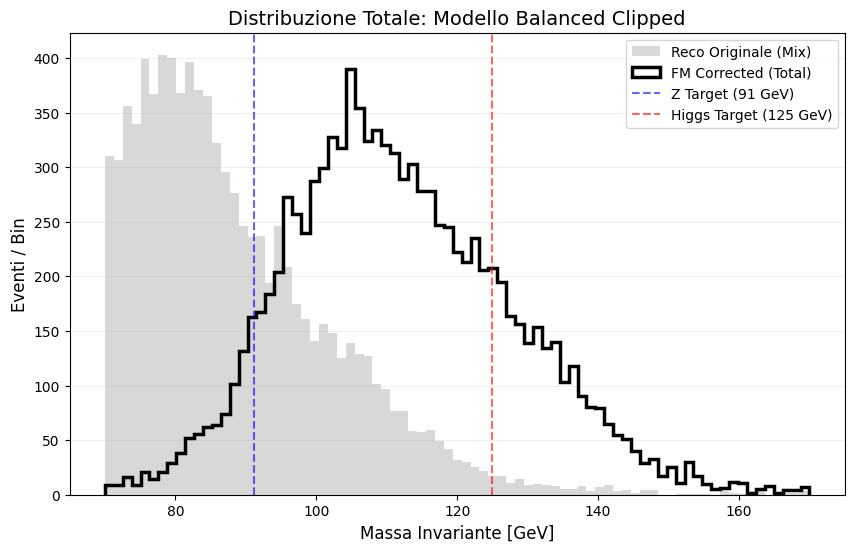

In [79]:
def plot_total_distribution(m_inv_pred, df_ref, title="Confronto Distribuzione Totale"):
    plt.figure(figsize=(10, 6))
    bins = np.linspace(70, 170, 80)
    
    # Massa Reco originale (Totale: Higgs + DY)
    plt.hist(df_ref["inv_mass_reco"], bins=bins, alpha=0.3, color='gray', 
             label='Reco Originale (Mix)', histtype='stepfilled')
    
    # Massa Corretta dal Flow Matching (Totale: Higgs + DY)
    plt.hist(m_inv_pred, bins=bins, color='black', lw=2.5, 
             label='FM Corrected (Total)', histtype='step')
    
    # Linee di riferimento fisiche
    plt.axvline(91.18, color='blue', ls='--', alpha=0.6, label='Z Target (91 GeV)')
    plt.axvline(125, color='red', ls='--', alpha=0.6, label='Higgs Target (125 GeV)')
    
    plt.title(title, fontsize=14)
    plt.xlabel("Massa Invariante [GeV]", fontsize=12)
    plt.ylabel("Eventi / Bin", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.2)
    plt.show()

# Esecuzione per il modello migliore (Clipped)
plot_total_distribution(m_inv_clipped, test_bal, title="Distribuzione Totale: Modello Balanced Clipped")

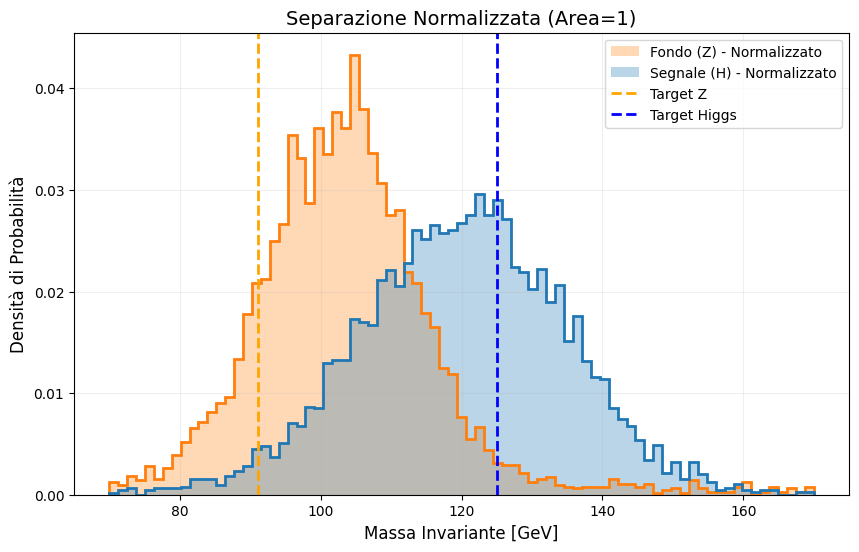

In [83]:
def plot_normalized_separation(m_inv_pred, df_ref, title="Separazione Normalizzata (Area=1)"):
    mask_h = (df_ref["class"] == 1)
    mask_dy = (df_ref["class"] == 0)
    
    plt.figure(figsize=(10, 6))
    bins = np.linspace(70, 170, 80)
    
    # Plot Drell-Yan normalizzato
    plt.hist(m_inv_pred[mask_dy], bins=bins, density=True, alpha=0.3, 
             color='tab:orange', label='Fondo (Z) - Normalizzato', histtype='stepfilled')
    plt.hist(m_inv_pred[mask_dy], bins=bins, density=True, 
             color='tab:orange', lw=2, histtype='step')
    
    # Plot Higgs normalizzato
    plt.hist(m_inv_pred[mask_h], bins=bins, density=True, alpha=0.3, 
             color='tab:blue', label='Segnale (H) - Normalizzato', histtype='stepfilled')
    plt.hist(m_inv_pred[mask_h], bins=bins, density=True, 
             color='tab:blue', lw=2, histtype='step')
    
    # Linee target
    plt.axvline(91.18, color='orange', ls='--', lw=2, label='Target Z')
    plt.axvline(125, color='blue', ls='--', lw=2, label='Target Higgs')
    
    plt.title(title, fontsize=14)
    plt.xlabel("Massa Invariante [GeV]", fontsize=12)
    plt.ylabel("Densità di Probabilità", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# Eseguiamo per il modello Balanced Clipped
plot_normalized_separation(m_inv_clipped, test_bal)

# 3. Flat Samples + Fine Tuning

In [84]:
# --------- Apro i samples flat  ------------
VBF = np.load("VBFtoXto2Tau_M-30to300.npz")

print(VBF.files)

['x_taus', 'x_tauprod', 'x_met', 'x_jets', 'x_neutrinos', 'x_gen', 'm_vis', 'm_vis_ptcorr', 'm_gen', 'm_gen_pt_vis_angles', 'm_vis_ptcorr_plus_nu', 'm_tauprod_nu', 'm_vis_nu_vis', 'm_fastmtt']


In [85]:
# check :
print("x_taus:", VBF["x_taus"].shape)
print("x_taus_gen", VBF["x_gen"].shape)
print("x_met :", VBF["x_met"].shape)
print("x_jets:", VBF["x_jets"].shape)
print("m_gen :", VBF["m_gen"].shape)

x_taus: (632014, 2, 18)
x_taus_gen (632014, 2, 4)
x_met : (632014, 1, 8)
x_jets: (632014, 3, 4)
m_gen : (632014,)


In [86]:
taus = VBF["x_taus"]        # shape (N, 2, 18)
# tauprod = VBF["x_tauprod"]  # shape (N, 10, 10)
tau_gen = VBF["x_gen"]       # shape (N, 2,  4)
met = VBF["x_met"]          # shape (N, 1, 8)
jets = VBF["x_jets"]        # shape (N, 3, 4)

m_vis_ptcorr = VBF["m_vis_ptcorr"]   # (N,)    --> La uso come m_reco
m_target = VBF["m_gen"]              # (N,)
m_vis = VBF["m_vis"]                 # (N,)
m_fastmtt = VBF["m_fastmtt"]         # (N,)


tau_features = [
    "logpt", "eta", "phi", "mass", "dxy", "dz",
    "ptCorrPNet", "rawPNetVSjet", "rawDeepTau2018v2p5VSjet",
    "charge",
    "dM_0", "dM_1", "dM_2", "dM_10", "dM_11",
    "leadTkDeltaEta", "leadTkDeltaPhi", "leadTkPtOverTauPt"
]

gen_tau_features = ["pt", "eta", "phi", "mass"]  # x_gen


import pandas as pd

N = taus.shape[0]

df = {}

# ---------- TAU 1 & TAU 2 ----------
for itau in [0, 1]:
    prefix = f"tau{itau+1}_"
    for i, feat in enumerate(tau_features):
        df[prefix + feat] = taus[:, itau, i]

# ---------- TAU GEN (TAU 1 & TAU 2) ----------
for itau in [0, 1]:
    prefix = f"gen_tau{itau+1}_"
    for i, feat in enumerate(gen_tau_features):
        df[prefix + feat] = tau_gen[:, itau, i]

# ---------- MET ----------
met_features = [
    "MET_logpt", "MET_phi", "MET_covXX", "MET_covXY",
    "MET_covYY", "MET_significance", "MET_sumEt", "MET_sumPtUnclustered"
]

for i, feat in enumerate(met_features):
    df[feat] = met[:, 0, i]

# ---------- JETS (3 jets) ----------
jet_features = ["logpt", "eta", "phi", "mass"]

for j in range(3):
    for i, feat in enumerate(jet_features):
        df[f"jet{j+1}_{feat}"] = jets[:, j, i]

# ---------- MASSE ----------
df["m_vis"]         = m_vis
df["m_vis_ptcorr"]  = m_vis_ptcorr
df["m_fastmtt"]     = m_fastmtt
df["m_gen"]         = m_target


df_flat = pd.DataFrame(df)

print(df_flat.shape)
df_flat.head()

(632014, 68)


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,m_vis,m_vis_ptcorr,m_fastmtt,m_gen
0,4.200094,1.643799,2.515137,2.949219,0.634277,5.184814,1.001953,0.999512,-1.000000,-1.0,...,-1.327881,5.281250,2.880777,1.763184,-0.800903,3.589844,24.438859,27.647144,33.020302,47.239086
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,1.614990,10.671875,2.833213,-0.185181,2.087402,3.179688,85.437739,93.784651,109.942673,106.047752
2,3.746890,-0.771606,2.914062,1.334961,0.001616,-0.001660,0.996582,0.883789,0.977051,1.0,...,0.796753,6.765625,3.711283,1.373779,2.641602,7.281250,61.325864,60.001639,83.316399,77.556129
3,3.882379,-1.166748,-0.862671,0.836914,-0.000545,0.000682,0.957031,0.780762,0.909668,1.0,...,2.308594,4.167969,3.327730,-2.611816,2.785645,4.589844,109.263026,97.097534,148.204529,102.891235
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,-2.422363,6.937500,3.800393,1.051758,2.386719,6.730469,104.564076,127.417169,143.905762,133.224426


In [88]:
df_flat["gen_tau1_logpt"] = np.log(np.clip(tau_gen[:, 0, 0], 1e-6, None))
df_flat["gen_tau2_logpt"] = np.log(np.clip(tau_gen[:, 1, 0], 1e-6, None))

log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df_flat["tau1_logpt"] > log_pt_min) & (df_flat["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_flat))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel_flat = df_flat[mask_pt].copy()

df_sel_flat["tau1_ptreco"] = np.exp(df_sel_flat["tau1_logpt"])
df_sel_flat["tau2_ptreco"] = np.exp(df_sel_flat["tau2_logpt"])

df_sel_flat["tau1_pt_reco_corrPNet"] = df_sel_flat["tau1_ptreco"] * df_sel_flat["tau1_ptCorrPNet"]
df_sel_flat["tau2_pt_reco_corrPNet"] = df_sel_flat["tau2_ptreco"] * df_sel_flat["tau2_ptCorrPNet"]
df_sel_flat

Eventi totali: 632014
Eventi che passano pT>30 GeV (in log): 394047


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


In [89]:
# tau ID

df_sel_flat_valid = df_sel_flat[
    (df_sel_flat["tau1_rawPNetVSjet"] != -1) &
    (df_sel_flat["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_flat_valid))

# Soglia al working point 90% :
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90

vals_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"].values
thresholds_tau1 = np.sort(np.unique(vals_tau1))

vals_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"].values
thresholds_tau2 = np.sort(np.unique(vals_tau2))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

# Applico le soglie event - level : 
mask_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_event  = mask_tau1 & mask_tau2

df_sel_tauID = df_sel_flat_valid[mask_event].copy()

# efficienza event-level 
eff_event = mask_event.mean() if len(df_sel_flat_valid) > 0 else float("nan")

print("Efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_event:.4f}")

df_flat_event = df_sel_tauID.copy()
df_flat_event

DY valid events = 391777
Efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8129


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


Before cut: 318494
After cut: 124121


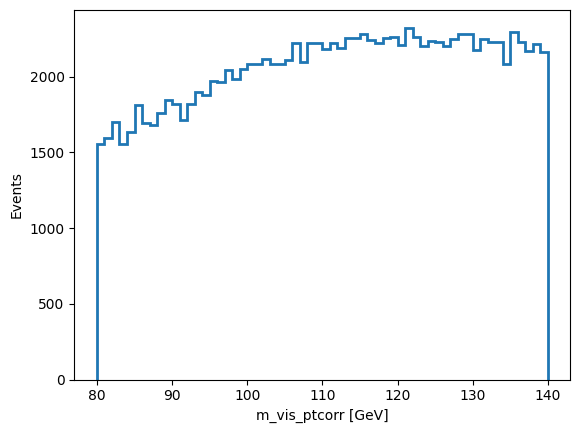

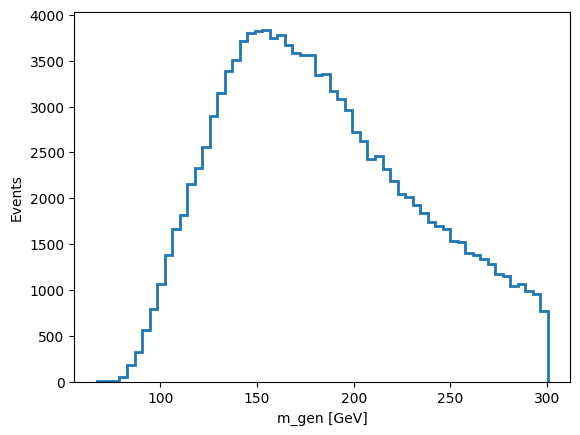

In [90]:
# taglio in massa -> su m_vis_ptcorr
print("Before cut:", len(df_flat_event))

df_flat_cut = df_flat_event[
    (df_flat_event["m_vis_ptcorr"] >= 80.0) &
    (df_flat_event["m_vis_ptcorr"] <= 140.0)
].copy()

print("After cut:", len(df_flat_cut))

# just checking 
import matplotlib.pyplot as plt

plt.hist(df_flat_cut["m_vis_ptcorr"], bins=60, histtype = 'step', linewidth = 2, density = False)   # -> Me lo aspetto quasi piatto 
plt.xlabel("m_vis_ptcorr [GeV]")
plt.ylabel("Events")
plt.show()


plt.hist(df_flat_cut["m_gen"], bins=60, histtype = 'step', linewidth = 2, density = False)
plt.xlabel("m_gen [GeV]")
plt.ylabel("Events")
plt.show()

In [91]:
# Preparazione per training 

eps = 1e-8

# Li rinomino coerentemente con il precedente modello :
df_flat_cut["tau1_pt_gen"] = df_flat_cut["gen_tau1_pt"]
df_flat_cut["tau2_pt_gen"] = df_flat_cut["gen_tau2_pt"]

# --- target: fattore di correzione ---
df_flat_cut["tau1_corr"] = df_flat_cut["tau1_pt_gen"] / np.clip(df_flat_cut["tau1_pt_reco_corrPNet"], eps, None)
df_flat_cut["tau2_corr"] = df_flat_cut["tau2_pt_gen"] / np.clip(df_flat_cut["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]

## Modello

In [101]:
from sklearn.preprocessing import StandardScaler
import joblib

# Inizializzo e fitto gli Scaler
scaler_flat_X = StandardScaler()
scaler_flat_y = StandardScaler()

X_flat_scaled = scaler_flat_X.fit_transform(df_flat_cut[train_cols].values)
y_flat_scaled = scaler_flat_y.fit_transform(df_flat_cut[y_cols].values)

# Salvo gli scaler (per l'inferenza)
joblib.dump(scaler_flat_X, "scaler_flat_X.pkl")
joblib.dump(scaler_flat_y, "scaler_flat_y.pkl")

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

# Conversione in Tensor
X_tensor = torch.tensor(X_flat_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_flat_scaled, dtype=torch.float32)
dataset_flat = TensorDataset(X_tensor, y_tensor)

# Split 80% Train - 20% Val
from sklearn.model_selection import train_test_split

# Dividiamo il dataframe flat in 80% train e 20% validation
df_train_flat, df_val_flat = train_test_split(df_flat_cut, test_size=0.2, random_state=42)

print(f"Dataset split: {len(df_train_flat)} training samples, {len(df_val_flat)} validation samples.")

# DataLoader
train_flat_loader = DataLoader(train_sub, batch_size=1024, shuffle=True, drop_last=True)
val_flat_loader = DataLoader(val_sub, batch_size=1024, shuffle=False)


Dataset split: 99296 training samples, 24825 validation samples.


In [102]:
import copy

# Lancio del training (la funzione restituirà il modello e lo scaler fitted)
model_flow_flat, scaler_ctx_flat = run_flow_training_v2(
    df_train_flat, 
    df_val_flat, 
    name="FLAT_UNBIASED_MODEL", 
    max_epochs=400, 
    patience=50, 
    lr=1e-3
)

# Salvataggio dei risultati per il modello Flat
torch.save(model_flow_flat.state_dict(), "fm_flat_unbiased.pth")
joblib.dump(scaler_ctx_flat, "scaler_ctx_flat.pkl")


>>> Training FLAT_UNBIASED_MODEL (Early Stopping)...
Epoch 000 | Val Loss: 0.208699
Epoch 010 | Val Loss: 0.067590
Epoch 020 | Val Loss: 0.026169
Epoch 030 | Val Loss: 0.020502
Epoch 040 | Val Loss: 0.014445
Epoch 050 | Val Loss: 0.015631
Epoch 060 | Val Loss: 0.010044
Epoch 070 | Val Loss: 0.013607
Epoch 080 | Val Loss: 0.011909
Epoch 090 | Val Loss: 0.013754
Epoch 100 | Val Loss: 0.009564
Epoch 110 | Val Loss: 0.010227
Epoch 120 | Val Loss: 0.010854
Epoch 130 | Val Loss: 0.009010
Epoch 140 | Val Loss: 0.009978
Epoch 150 | Val Loss: 0.012457
Epoch 160 | Val Loss: 0.007869
Epoch 170 | Val Loss: 0.012127
Epoch 180 | Val Loss: 0.006003
Epoch 190 | Val Loss: 0.009588
Epoch 200 | Val Loss: 0.008439
Epoch 210 | Val Loss: 0.009035
Epoch 220 | Val Loss: 0.010680
Epoch 230 | Val Loss: 0.007694


['scaler_ctx_flat.pkl']

In [103]:
def apply_flat_correction(model, scaler_ctx, df_test):
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Preparazione del contesto (Input)
    X_ctx = torch.tensor(df_test[train_cols].values, dtype=torch.float32).to(device)
    X_ctx_scaled = scaler_ctx.transform(X_ctx)
    
    # 2. Integrazione (Inferenza)
    # Parto da x0 = 1 perché il target è un rapporto centrato vicino a 1
    x0 = torch.ones((X_ctx.shape[0], 2)).to(device) 
    
    with torch.no_grad():
        # Risolvo l'ODE da t=0 a t=1
        steps = 10
        dt = 1.0 / steps
        xt = x0.clone()
        for i in range(steps):
            t = torch.ones((X_ctx.shape[0], 1)).to(device) * (i * dt)
            v = model(t, xt, X_ctx_scaled)
            xt = xt + v * dt
            
    # xt ora contiene i fattori di correzione predetti (tau1_corr, tau2_corr)
    corrections = xt.cpu().numpy()
    
    # 3. Applicazione della correzione fisica
    # pT_corr = pT_reco * fattore_predetto
    pT1_flat = df_test["tau1_pt_reco_corrPNet"].values * corrections[:, 0]
    pT2_flat = df_test["tau2_pt_reco_corrPNet"].values * corrections[:, 1]
    
    # Ricalcolo della Massa Invariante
    d_eta = df_test["tau1_eta"] - df_test["tau2_eta"]
    d_phi = np.arccos(np.cos(df_test["tau1_phi"] - df_test["tau2_phi"]))
    
    m_inv_flat = np.sqrt(2 * pT1_flat * pT2_flat * (np.cosh(d_eta) - np.cos(d_phi)))
    
    return m_inv_flat

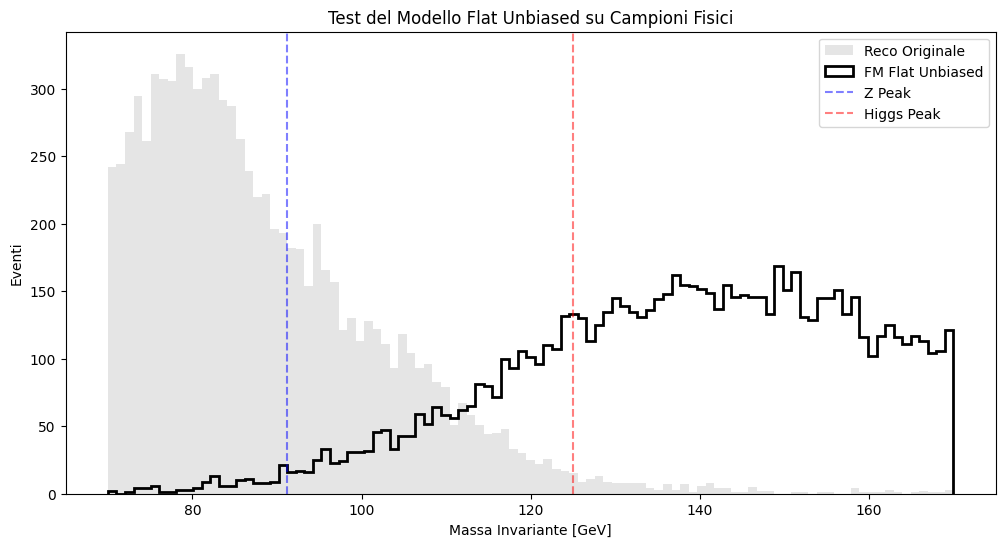

In [104]:
# Applico la correzione al test set bilanciato
m_inv_flat_final = apply_flat_correction(model_flow_flat, scaler_ctx_flat, test_bal)

# Plot di confronto
plt.figure(figsize=(12, 6))
bins = np.linspace(70, 170, 100)

# Massa Reco Originale
plt.hist(test_bal["inv_mass_reco"], bins=bins, alpha=0.2, color='gray', label='Reco Originale')

# Massa corretta dal modello FLAT (Unbiased)
plt.hist(m_inv_flat_final, bins=bins, histtype='step', lw=2, color='black', label='FM Flat Unbiased')

# Target fisici
plt.axvline(91.18, color='blue', ls='--', alpha=0.5, label='Z Peak')
plt.axvline(125, color='red', ls='--', alpha=0.5, label='Higgs Peak')

plt.title("Test del Modello Flat Unbiased su Campioni Fisici")
plt.xlabel("Massa Invariante [GeV]")
plt.ylabel("Eventi")
plt.legend()
plt.show()

In [105]:
# Calcolo delle metriche per il modello Flat Unbiased
res_flat = calculate_metrics_refined(m_inv_flat_final, test_bal, "FLAT UNBIASED")

# Massa Reco originale per confronto
res_reco_orig = calculate_metrics_refined(test_bal["inv_mass_reco"].values, test_bal, "RECO ORIGINAL")

In [106]:
import pandas as pd

data_final = {
    "Configurazione": [
        "Reco Originale", 
        "Balanced Clipped (Peak)", 
        "Flat Unbiased (Multiplicative)"
    ],
    "Risoluzione (Sigma) ": [
        f"{res_reco_orig['res']:.2f} GeV", 
        f"14.68 GeV", 
        f"{res_flat['res']:.2f} GeV"
    ],
    "S/B Ratio ": [
        f"{res_reco_orig['sob']:.3f}", 
        f"2.904", 
        f"{res_flat['sob']:.3f}"
    ],
    "KL Divergence ": [
        f"{res_reco_orig['kl']:.2f}", 
        f"8.40", 
        f"{res_flat['kl']:.2f}"
    ]
}

df_comparison_final = pd.DataFrame(data_final)
print("\n--- CONFRONTO FINALE DELLE PERFORMANCE ---")
print(df_comparison_final.to_string(index=False))


--- CONFRONTO FINALE DELLE PERFORMANCE ---
                Configurazione Risoluzione (Sigma)  S/B Ratio  KL Divergence 
                Reco Originale            15.18 GeV      6.168          11.03
       Balanced Clipped (Peak)            14.68 GeV      2.904           8.40
Flat Unbiased (Multiplicative)            26.29 GeV      0.515          16.19


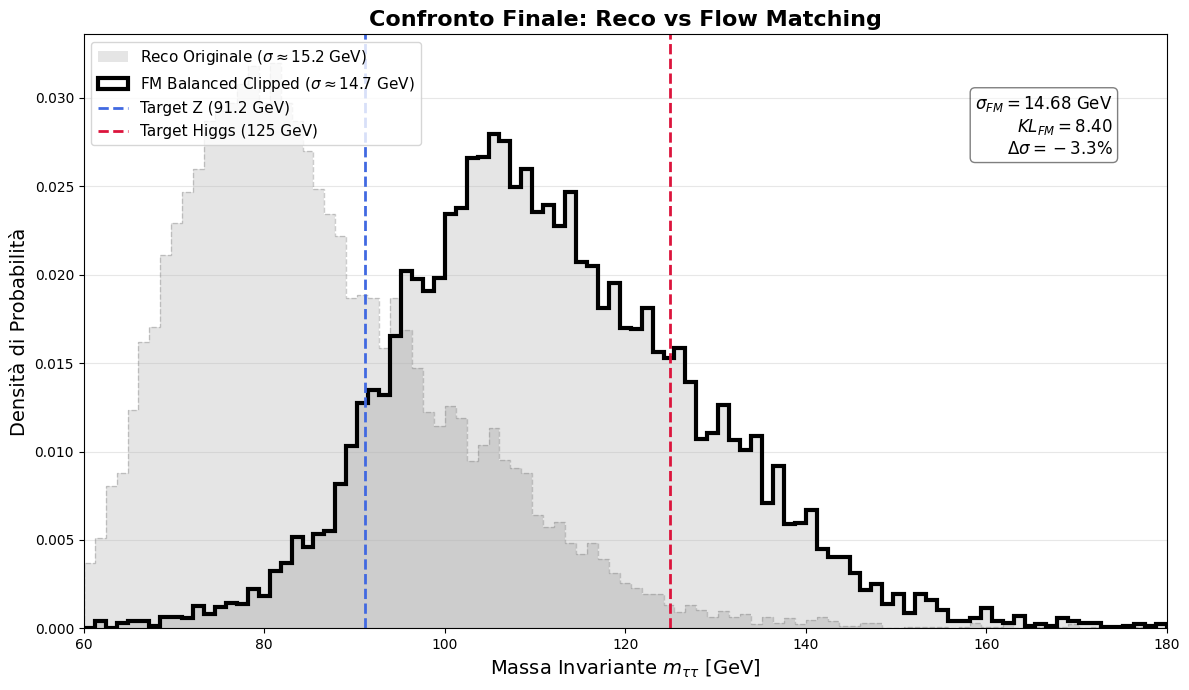

In [113]:
import numpy as np
import matplotlib.pyplot as plt

def plot_final_comparison_fixed(m_inv_best, test_df, title="Confronto Finale: Reco vs Flow Matching"):
    # Pulizia dati per sicurezza
    m_inv_best = m_inv_best[np.isfinite(m_inv_best)]
    m_reco_orig = test_df["inv_mass_reco"].values
    m_reco_orig = m_reco_orig[np.isfinite(m_reco_orig)]

    plt.figure(figsize=(12, 7))
    bins = np.linspace(60, 180, 100)
    
    # 1. Distribuzione Originale - NOTA: prefisso 'r' per le raw strings
    plt.hist(m_reco_orig, bins=bins, alpha=0.2, color='gray', 
             label=r'Reco Originale ($\sigma \approx 15.2$ GeV)', density=True)
    plt.hist(m_reco_orig, bins=bins, histtype='step', color='gray', 
             alpha=0.4, ls='--', density=True)

    # 2. Miglior Modello - NOTA: prefisso 'r'
    plt.hist(m_inv_best, bins=bins, histtype='step', lw=3, color='black', 
             label=r'FM Balanced Clipped ($\sigma \approx 14.7$ GeV)', density=True)
    plt.hist(m_inv_best, bins=bins, alpha=0.1, color='black', density=True)

    # 3. Reference Fisiche
    plt.axvline(91.18, color='royalblue', ls='--', lw=2, label='Target Z (91.2 GeV)')
    plt.axvline(125.0, color='crimson', ls='--', lw=2, label='Target Higgs (125 GeV)')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(r"Massa Invariante $m_{\tau\tau}$ [GeV]", fontsize=14)
    plt.ylabel("Densità di Probabilità", fontsize=14)
    
    # Costruzione stringa metriche con raw strings e raddoppio graffe per f-string
    textstr = (r"$\sigma_{FM} = 14.68$ GeV" + "\n" +
               r"$KL_{FM} = 8.40$" + "\n" +
               r"$\Delta \sigma = -3.3\%$")
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.text(0.95, 0.90, textstr, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.legend(loc='upper left', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(60, 180)
    plt.tight_layout()
    plt.show()

# Esecuzione
plot_final_comparison_fixed(m_inv_clipped, test_bal)

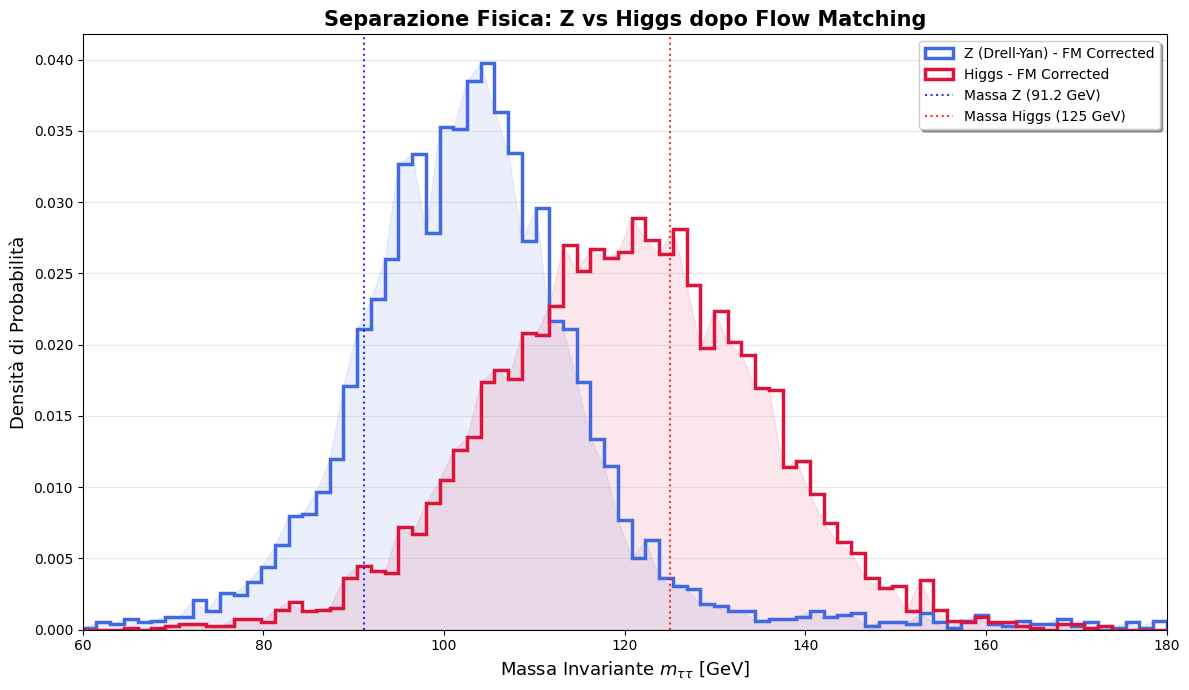

In [115]:
def plot_separated_components_class(m_inv_best, test_df):
    plt.figure(figsize=(12, 7))
    bins = np.linspace(60, 180, 80)
    
    # 1. Selezione tramite la colonna 'class'
    # 1 = Higgs, 0 = Z (Drell-Yan)
    idx_higgs = (test_df['class'] == 1).values
    idx_z = (test_df['class'] == 0).values
    
    # 2. Plot Componente Z (Drell-Yan)
    plt.hist(m_inv_best[idx_z], bins=bins, histtype='step', lw=2.5, 
             color='royalblue', label='Z (Drell-Yan) - FM Corrected', density=True)
    plt.fill_between(bins[:-1], 0, np.histogram(m_inv_best[idx_z], bins=bins, density=True)[0], 
                     color='royalblue', alpha=0.1)

    # 3. Plot Componente Higgs
    plt.hist(m_inv_best[idx_higgs], bins=bins, histtype='step', lw=2.5, 
             color='crimson', label='Higgs - FM Corrected', density=True)
    plt.fill_between(bins[:-1], 0, np.histogram(m_inv_best[idx_higgs], bins=bins, density=True)[0], 
                     color='crimson', alpha=0.1)

    # 4. Linee di riferimento (Target teorici)
    plt.axvline(91.18, color='blue', ls=':', alpha=0.8, label='Massa Z (91.2 GeV)')
    plt.axvline(125.0, color='red', ls=':', alpha=0.8, label='Massa Higgs (125 GeV)')

    plt.title("Separazione Fisica: Z vs Higgs dopo Flow Matching", fontsize=15, fontweight='bold')
    plt.xlabel("Massa Invariante $m_{\\tau\\tau}$ [GeV]", fontsize=13)
    plt.ylabel("Densità di Probabilità", fontsize=13)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(60, 180)
    plt.tight_layout()
    plt.show()

# Esecuzione
plot_separated_components_class(m_inv_clipped, test_bal)

# 4. (Test Extra) Uso la MAE
Il compito però cambia, diventa un task di regressione (punto a punto)

In [120]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Suddivisione Training e Validation 
df_train_z, df_val_z = train_test_split(df_DY_event, test_size=0.2, random_state=42)
df_train_h, df_val_h = train_test_split(df_H_event, test_size=0.2, random_state=42)

# 2. Bilanciamento delle classi nel Training Set
n_samples = max(len(df_train_z), len(df_train_h))
df_train_h_bal = df_train_h.sample(n_samples, replace=True, random_state=42)
df_train_bal = pd.concat([df_train_z, df_train_h_bal]).sample(frac=1).reset_index(drop=True)

# 3. Creazione set per Validation 
df_val_bal = pd.concat([df_val_z, df_val_h]).sample(frac=1).reset_index(drop=True)

# 4. Applicazione del Clipping (Range 80 - 140 GeV)
mass_min, mass_max = 80, 140
df_train_clipped = df_train_bal[
    (df_train_bal['inv_mass_reco'] >= mass_min) & 
    (df_train_bal['inv_mass_reco'] <= mass_max)
].copy()

df_val_clipped = df_val_bal[
    (df_val_bal['inv_mass_reco'] >= mass_min) & 
    (df_val_bal['inv_mass_reco'] <= mass_max)
].copy()

print(f"Dataset pronti per MAE:")
print(f" - Train clipped: {len(df_train_clipped)} eventi")
print(f" - Val clipped:   {len(df_val_clipped)} eventi")


Dataset pronti per MAE:
 - Train clipped: 95172 eventi
 - Val clipped:   23769 eventi


In [121]:
# Lancio del training MAE
model_mae, scaler_mae = run_regression_training_mae(
    df_train_clipped, 
    df_val_clipped, 
    train_cols=train_cols, 
    y_cols=y_cols, 
    name="MAE_REGRESSOR",
    max_epochs=400,
    patience=40,
    lr=5e-4
)


>>> Training MAE_REGRESSOR with MAE Loss...
Epoch 000 | Val MAE: 0.179110
Epoch 010 | Val MAE: 0.164780
Epoch 020 | Val MAE: 0.159722
Epoch 030 | Val MAE: 0.156088
Epoch 040 | Val MAE: 0.151748
Epoch 050 | Val MAE: 0.150535
Epoch 060 | Val MAE: 0.151000
Epoch 070 | Val MAE: 0.148253
Epoch 080 | Val MAE: 0.146196
Epoch 090 | Val MAE: 0.147116
Epoch 100 | Val MAE: 0.147149
Epoch 110 | Val MAE: 0.148181
Epoch 120 | Val MAE: 0.148405


In [123]:
def get_mae_predictions(model, scaler, df_test):
    model.eval()
    device = next(model.parameters()).device
    
    # Prepara il contesto (input)
    X_ctx = torch.tensor(df_test[train_cols].values, dtype=torch.float32).to(device)
    X_ctx_scaled = scaler.transform(X_ctx)
    
    with torch.no_grad():
        # Input dummy per t e x (richiesti dalla struttura della tua rete)
        t_dummy = torch.zeros((X_ctx.shape[0], 1)).to(device)
        x_dummy = torch.zeros((X_ctx.shape[0], 2)).to(device)
        
        # Il modello restituisce i fattori di correzione predetti [tau1_corr, tau2_corr]
        preds = model(t_dummy, x_dummy, X_ctx_scaled).cpu().numpy()
    
    # Applichiamo le correzioni ai pT originali (PNet)
    pT1_corr = df_test["tau1_pt_reco_corrPNet"].values * preds[:, 0]
    pT2_corr = df_test["tau2_pt_reco_corrPNet"].values * preds[:, 1]
    
    # Calcolo della massa invariante corretta
    d_eta = df_test["tau1_eta"] - df_test["tau2_eta"]
    d_phi = np.arccos(np.cos(df_test["tau1_phi"] - df_test["tau2_phi"]))
    m_inv_mae = np.sqrt(2 * pT1_corr * pT2_corr * (np.cosh(d_eta) - np.cos(d_phi)))
    
    return m_inv_mae

# Calcoliamo la massa per il set di validazione
m_inv_mae_res = get_mae_predictions(model_mae, scaler_mae, df_val_bal)

/opt/homebrew/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/m1/hdc57b7d7v9_z7xtd8slwkgr0000gn/T/ipykernel_32122/2806641675.py:21: SyntaxWarning: invalid escape sequence '\m'
  label=f'Reco: $\mu={mu_reco:.1f}$, $\sigma={std_reco:.1f}$ GeV')
/var/folders/m1/hdc57b7d7v9_z7xtd8slwkgr0000gn/T/ipykernel_32122/2806641675.py:21: SyntaxWarning: invalid escape sequence '\s'
  label=f'Reco: $\mu={mu_reco:.1f}$, $\sigma={std_reco:.1f}$ GeV')


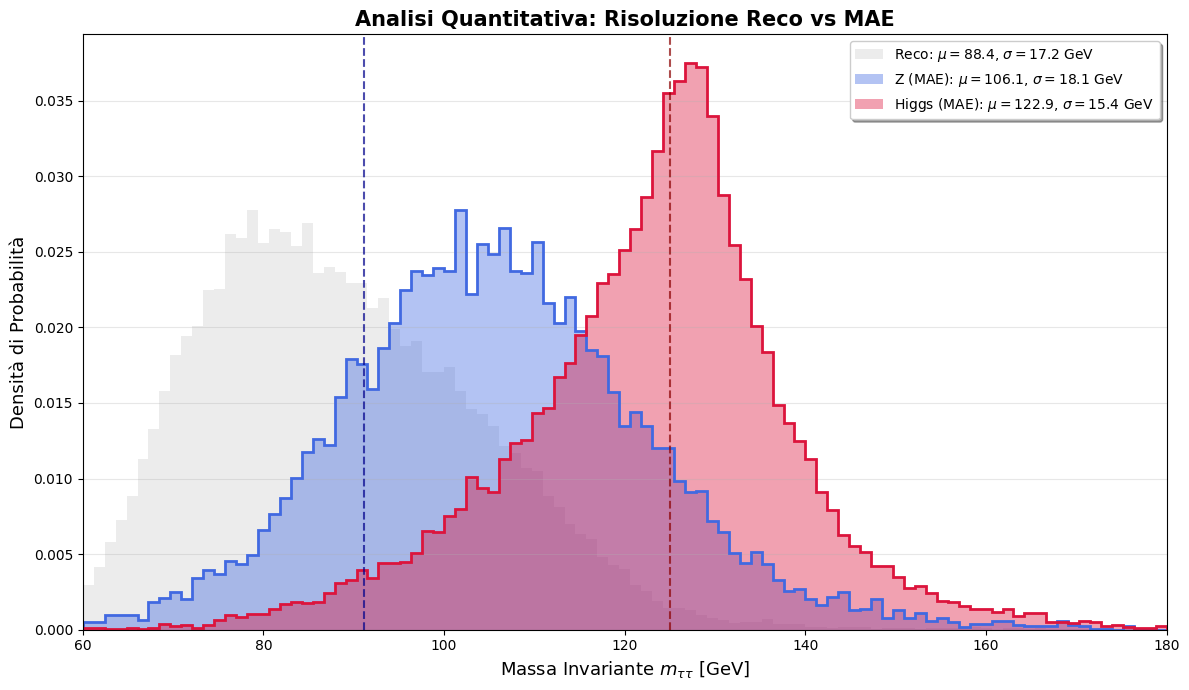

In [128]:
def plot_mae_vs_reco_with_stats(m_inv_pred, df_test):
    plt.figure(figsize=(12, 7))
    bins = np.linspace(60, 180, 100)
    
    # --- CALCOLO STATISTICHE ---
    # Reco Originale
    m_reco = df_test['inv_mass_reco']
    mu_reco, std_reco = m_reco.mean(), m_reco.std()
    
    # MAE Z (Class 0)
    m_z_mae = m_inv_pred[df_test['class'] == 0]
    mu_z, std_z = m_z_mae.mean(), m_z_mae.std()
    
    # MAE Higgs (Class 1)
    m_h_mae = m_inv_pred[df_test['class'] == 1]
    mu_h, std_h = m_h_mae.mean(), m_h_mae.std()

    # --- PLOTTING ---
    # 1. Massa Reco Originale
    plt.hist(m_reco, bins=bins, alpha=0.15, color='gray', density=True,
             label=f'Reco: $\mu={mu_reco:.1f}$, $\sigma={std_reco:.1f}$ GeV')
    
    # 2. MAE Z
    plt.hist(m_z_mae, bins=bins, alpha=0.4, color='royalblue', density=True,
             label=f'Z (MAE): $\mu={mu_z:.1f}$, $\sigma={std_z:.1f}$ GeV')
    plt.hist(m_z_mae, bins=bins, histtype='step', color='royalblue', lw=2, density=True)
    
    # 3. MAE Higgs
    plt.hist(m_h_mae, bins=bins, alpha=0.4, color='crimson', density=True,
             label=f'Higgs (MAE): $\mu={mu_h:.1f}$, $\sigma={std_h:.1f}$ GeV')
    plt.hist(m_h_mae, bins=bins, histtype='step', color='crimson', lw=2, density=True)
    
    # Riferimenti fisici
    plt.axvline(91.18, color='darkblue', ls='--', lw=1.5, alpha=0.7)
    plt.axvline(125.0, color='darkred', ls='--', lw=1.5, alpha=0.7)
    
    plt.title("Analisi Quantitativa: Risoluzione Reco vs MAE", fontsize=15, fontweight='bold')
    plt.xlabel("Massa Invariante $m_{\\tau\\tau}$ [GeV]", fontsize=13)
    plt.ylabel("Densità di Probabilità", fontsize=13)
    
    # Legenda posizionata in modo che non copra i picchi
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(60, 180)
    plt.tight_layout()
    plt.show()

# Esecuzione
plot_mae_vs_reco_with_stats(m_inv_mae_res, df_val_bal)